# Customer Churn Analysis

## Objective
The goal of this project is to analyze customer churn behavior and build a predictive model to identify customers likely to churn.

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for model
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score, roc_curve, roc_auc_score

## Load Dataset

In [153]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Exploratory Data Analysis (EDA)

In this section, we explore patterns in the data to understand factors affecting customer churn.

In [154]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [155]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [156]:
df.shape

(7043, 33)

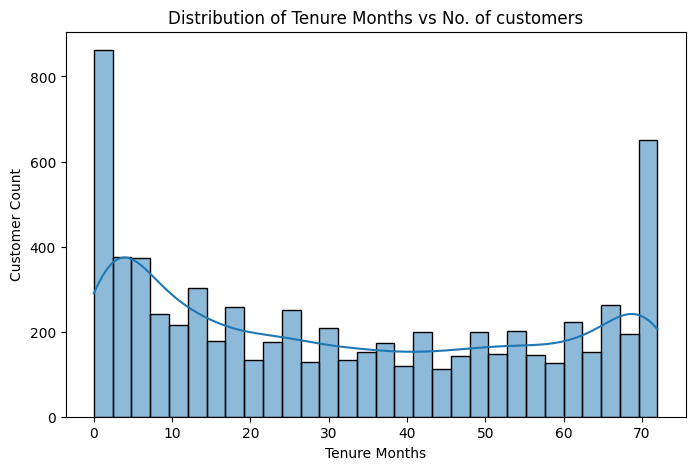

In [157]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months vs No. of customers')
plt.show()

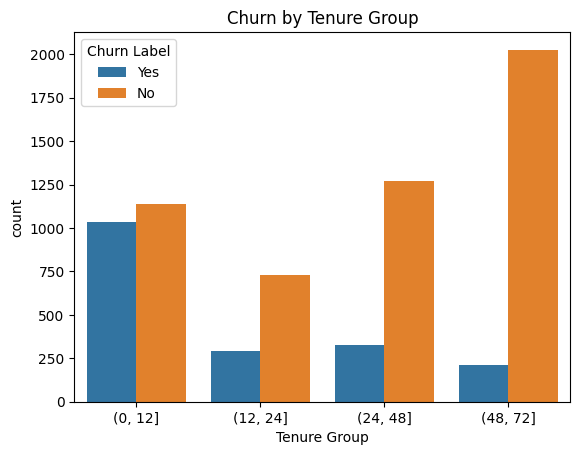

In [158]:
df['Tenure Group'] = pd.cut(df['Tenure Months'], bins=[0,12,24,48,72])

sns.countplot(x='Tenure Group', hue='Churn Label', data=df)
plt.title("Churn by Tenure Group")
plt.show()

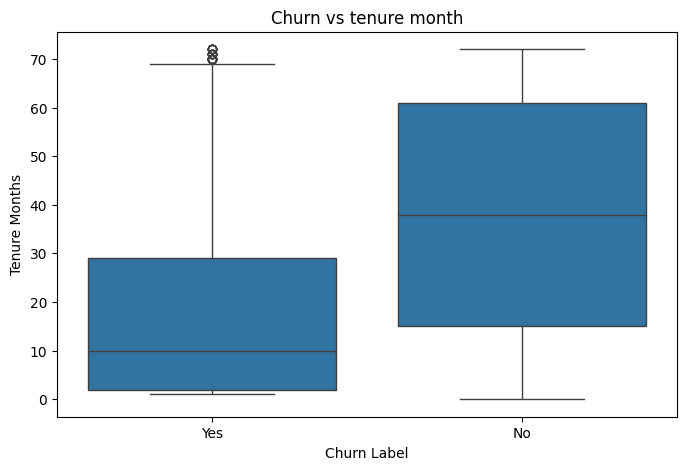

In [159]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Tenure Months', data = df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs tenure month')
plt.show()

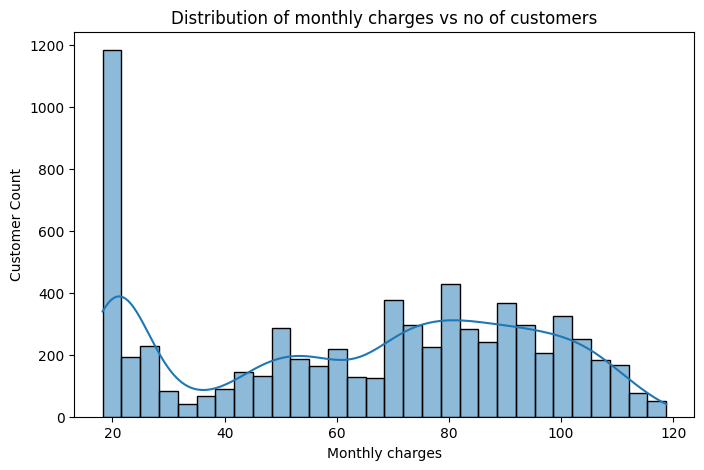

In [160]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('Monthly charges')
plt.ylabel('Customer Count')
plt.title('Distribution of monthly charges vs no of customers')
plt.show()

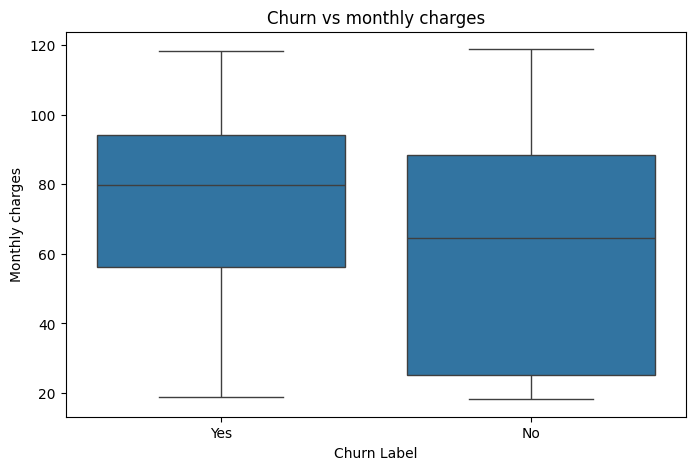

In [161]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Monthly Charges', data = df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly charges')
plt.title('Churn vs monthly charges')
plt.show()

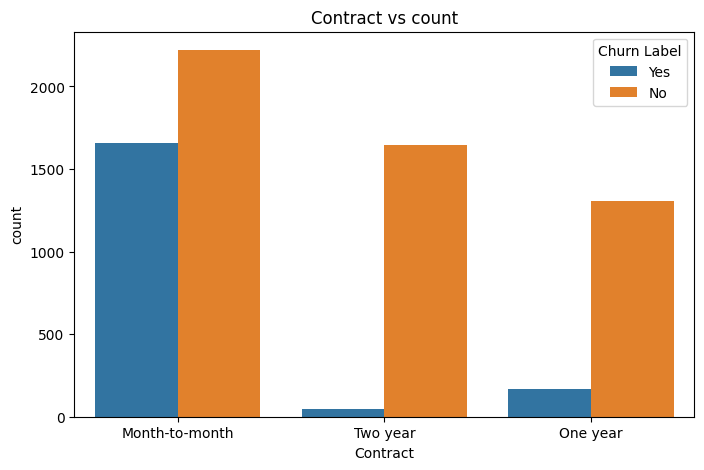

In [162]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Contract', hue='Churn Label', data = df)
plt.xlabel('Contract')
plt.ylabel('count')
plt.title('Contract vs count')
plt.show()

In [163]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


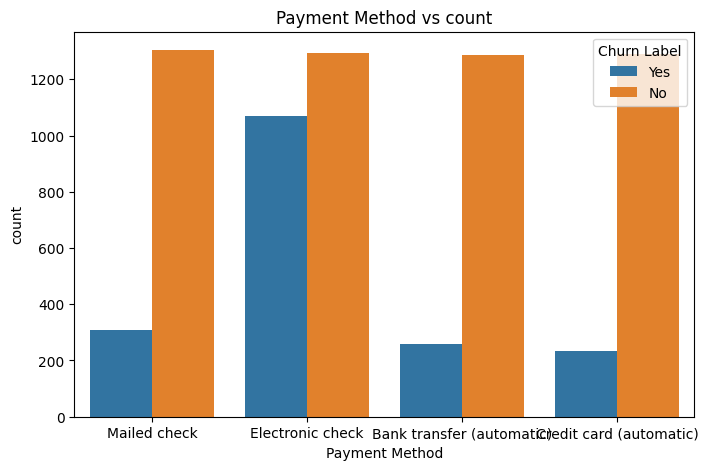

In [164]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Payment Method', hue='Churn Label', data = df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

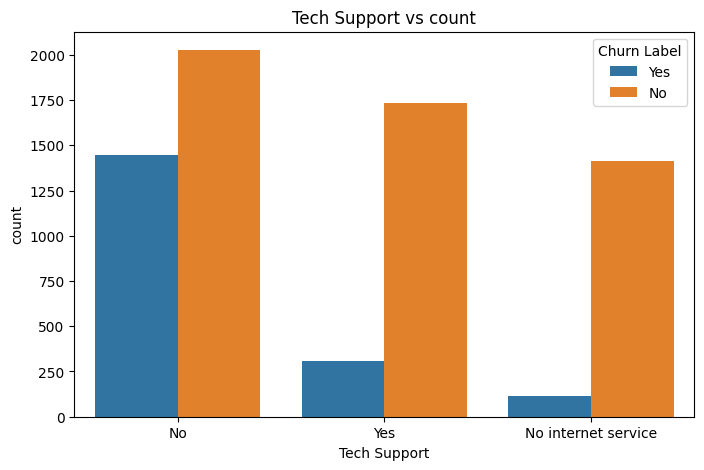

In [165]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Tech Support', hue='Churn Label', data = df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


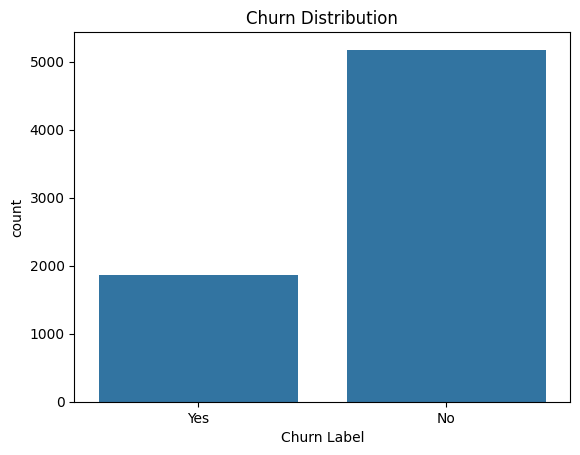

In [166]:
print(df['Churn Label'].value_counts(normalize=True))

sns.countplot(x='Churn Label', data=df)
plt.title("Churn Distribution")
plt.show()

In [167]:
avg_tenure = df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [168]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


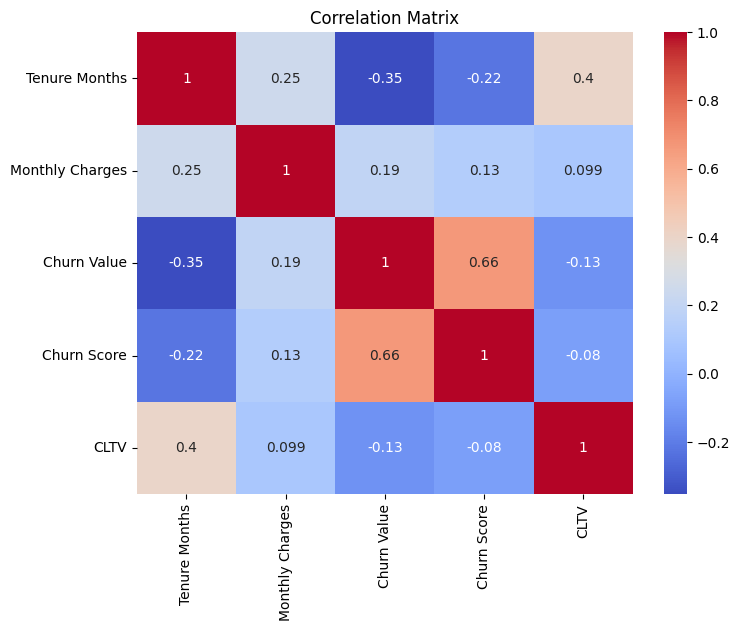

In [169]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [170]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize = 'index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


### Key Insights from EDA:
1.   Month-to-month contracts have highest churn
2.   Customers with high monthly charges churn more
3.   Low tenure customers are more likely to churn
4.   Electronic check users show higher churn rate
5.   Customers with no tech support are more likely to churn





## Data Cleaning
(A) Handling missing values and fixing data types.

In [171]:
# Convert Total Charges from object dtype to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("Total Charges(dtype):", df['Total Charges'].dtype)

# Checking missing values
print("Null Count:", df['Total Charges'].isnull().sum())

Total Charges(dtype): float64
Null Count: 11


In [172]:
# Check rows where Total Charges is missing
print(df[df['Total Charges'].isnull()]['Tenure Months'])

# Check how many such rows exist
print("Shape:", df[df['Total Charges'].isnull()]['Tenure Months'].shape)

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64
Shape: (11,)


In [173]:
# Fill missing values
df['Total Charges'] = df['Total Charges'].fillna(0)

# Verify missing values are handled
df['Total Charges'].isnull().sum()

np.int64(0)

(B) Removing columns that do not contribute to analysis.

In [174]:
drop_columns = ['CustomerID', 'Count', 'Country', 'State', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason', 'City']
df = df.drop(columns = drop_columns)
print("Shape after removing irrelevant columns: ", df.shape)

Shape after removing irrelevant columns:  (7043, 21)


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             7043 non-null   object  
 1   Senior Citizen     7043 non-null   object  
 2   Partner            7043 non-null   object  
 3   Dependents         7043 non-null   object  
 4   Tenure Months      7043 non-null   int64   
 5   Phone Service      7043 non-null   object  
 6   Multiple Lines     7043 non-null   object  
 7   Internet Service   7043 non-null   object  
 8   Online Security    7043 non-null   object  
 9   Online Backup      7043 non-null   object  
 10  Device Protection  7043 non-null   object  
 11  Tech Support       7043 non-null   object  
 12  Streaming TV       7043 non-null   object  
 13  Streaming Movies   7043 non-null   object  
 14  Contract           7043 non-null   object  
 15  Paperless Billing  7043 non-null   object  
 16  Paymen

Columns like CustomerID, location fields, and CLTV were removed as they either had high cardinality, risk of leakage, or were not useful for prediction.

## Encoding

In this step, categorical variables are converted into numerical format to prepare the dataset for machine learning models, using one hot encoding.


In [176]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("Encoded data shape:", (df_encoded.shape))
df_encoded.head()

Encoded data shape: (7043, 34)


,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,"Tenure Group_(12, 24]","Tenure Group_(24, 48]","Tenure Group_(48, 72]"
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,True,False,True,False,False,False,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,True,False,False,True,False,True,False,False,False,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,True,False,False,True,False,True,False,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,True,False,False,True,False,False,False,False,False,True


In [177]:
X = df_encoded.drop('Churn Value', axis = 1)
Y = df_encoded['Churn Value']

print(X.shape)
print(Y.shape)

(7043, 33)
(7043,)


In [178]:
df_encoded.to_csv("processed_data.csv", index=False)

## Machine Learning Implementation

### Train Test Split

In [179]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('Y_train:', Y_train.shape)
print('Y_test: ', Y_test.shape)

X_train: (5634, 33)
X_test:  (1409, 33)
Y_train: (5634,)
Y_test:  (1409,)


### Random Forest Classifier

In [180]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(Y_test, y_pred)
print("Confusion Matrix:\n", cm)

print(classification_report(Y_test, y_pred))

Accuracy: 0.7920511000709723
Confusion Matrix:
 [[909 100]
 [193 207]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



#### **Approach 1: Handle Class imbalance**

In [181]:
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, Y_train)
y_pred_balanced = rf_balanced.predict(X_test)
accuracy_balanced = accuracy_score(Y_test, y_pred_balanced)
cm_balanced=confusion_matrix(Y_test, y_pred_balanced)

print('Accuracy (Balanced):', accuracy_balanced)
print('Confusion Matrix:\n', cm_balanced)
print (classification_report (Y_test, y_pred_balanced))

Accuracy (Balanced): 0.7920511000709723
Confusion Matrix:
 [[912  97]
 [196 204]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.68      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



#### **Approach 2: Hyperparameter Tuning**

In [182]:
rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tuned.fit(X_train, Y_train)
y_pred_tuned=rf_tuned.predict(X_test)
accuracy_tuned = accuracy_score(Y_test, y_pred_tuned)
cm_tuned = confusion_matrix(Y_test, y_pred_tuned)

print('Accuracy (Tuned):', accuracy_tuned)
print('Confusion Matrix:\n', cm_tuned)
print (classification_report(Y_test, y_pred_tuned))

Accuracy (Tuned): 0.7799858055358411
Confusion Matrix:
 [[798 211]
 [ 99 301]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



#### **Approach 3: Feature Importance Analysis**

In [183]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuned.feature_importances_
    })
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                                   Feature  Importance
0                            Tenure Months    0.159883
2                            Total Charges    0.119510
1                          Monthly Charges    0.092822
25                       Contract_Two year    0.087602
6                           Dependents_Yes    0.065925
10            Internet Service_Fiber optic    0.064680
32                   Tenure Group_(48, 72]    0.044747
28         Payment Method_Electronic check    0.043455
24                       Contract_One year    0.033396
19                        Tech Support_Yes    0.022676
13                     Online Security_Yes    0.021725
26                   Paperless Billing_Yes    0.019511
16   Device Protection_No internet service    0.015584
5                              Partner_Yes    0.014480
18        Tech Support_No internet service    0.014450
14       Online Backup_No internet service    0.013268
11                     Internet Service_No    0.013150
20        

In [184]:
# 15 least important features
print(feature_importance .tail(15))

                                   Feature  Importance
3                              Gender_Male    0.012477
12     Online Security_No internet service    0.011703
15                       Online Backup_Yes    0.011464
9                       Multiple Lines_Yes    0.011416
22    Streaming Movies_No internet service    0.011181
31                   Tenure Group_(24, 48]    0.010733
4                       Senior Citizen_Yes    0.010562
23                    Streaming Movies_Yes    0.009658
21                        Streaming TV_Yes    0.009611
27  Payment Method_Credit card (automatic)    0.009581
17                   Device Protection_Yes    0.009009
29             Payment Method_Mailed check    0.008509
30                   Tenure Group_(12, 24]    0.006562
8          Multiple Lines_No phone service    0.004008
7                        Phone Service_Yes    0.003554


In [185]:
# Drop least important features
X_selected = X.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis = 1)

X_train_sel, X_test_sel,  Y_train_sel, Y_test_sel = train_test_split(X_selected, Y, test_size=0.2, random_state=42)

rf_selected = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel, Y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)
print(classification_report(Y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.78      0.79      1409



### Hyperparameter Grid Search





In [186]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=(5,10,15,20)
results=[]

for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth, random_state=42,class_weight='balanced')
    rf.fit(X_train, Y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    recall=recall_score(Y_test,y_pred)
    precision=precision_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append ({'Trees': n_trees, 'Depth': depth, 'Accuracy': accuracy, 'Recall': recall, 'precision': precision, 'F1 Score':f1})
result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['Recall','Accuracy'], ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  precision  F1 Score
0     100      5  0.747339  0.8025   0.536789  0.643287
4     200      5  0.746629  0.8000   0.536013  0.641926
8     300      5  0.741661  0.8000   0.529801  0.637450
16    500      5  0.741661  0.8000   0.529801  0.637450
12    400      5  0.740951  0.8000   0.528926  0.636816
5     200     10  0.779276  0.7550   0.586408  0.660109
13    400     10  0.780696  0.7525   0.589041  0.660812
9     300     10  0.779986  0.7525   0.587891  0.660088
17    500     10  0.781405  0.7475   0.590909  0.660044
1     100     10  0.776437  0.7475   0.582846  0.654984
14    400     15  0.801987  0.6300   0.657963  0.643678
18    500     15  0.801987  0.6300   0.657963  0.643678
10    300     15  0.801278  0.6300   0.656250  0.642857
6     200     15  0.800568  0.6225   0.656992  0.639281
2     100     15  0.801987  0.6150   0.663073  0.638132
3     100     20  0.795600  0.5450   0.672840  0.602210
11    300     20  0.796309  0.5400   0.677116  0

### Model Comparison Table

In [187]:
models_comparison = pd.DataFrame({
    'Model': ['Baseline Random Forest', 'Balanced Random Forest', 'Tuned Random Forest'],
    'Accuracy':  [
        round(accuracy_score(Y_test, y_pred), 3),
        round(accuracy_balanced, 3),
        round(accuracy_tuned, 3)
    ],
    'Recall': [
        round(recall_score(Y_test, y_pred), 3),
        round(recall_score(Y_test, y_pred_balanced), 3),
        round(recall_score(Y_test, y_pred_tuned), 3)
    ],
    'Precision': [
        round(precision_score(Y_test, y_pred), 3),
        round(precision_score(Y_test, y_pred_balanced), 3),
        round(precision_score(Y_test, y_pred_tuned), 3)
    ],
    'F1 Score': [
        round(f1_score(Y_test, y_pred), 3),
        round(f1_score(Y_test, y_pred_balanced), 3),
        round(f1_score(Y_test, y_pred_tuned), 3)
    ]
})
print(models_comparison.to_string(index=False))

                 Model  Accuracy  Recall  Precision  F1 Score
Baseline Random Forest     0.797   0.537      0.680     0.601
Balanced Random Forest     0.792   0.510      0.678     0.582
   Tuned Random Forest     0.780   0.752      0.588     0.660


Tuned Random Forest has the best recall

### Cross Validation

In [188]:
final_rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
cv_accuracy = cross_val_score(final_rf, X, Y, cv = 5, scoring = 'accuracy')
print("CV Accuracy: ", cv_accuracy)
print("Mean (CV Accuracy): ", cv_accuracy.mean())

CV Accuracy:  [0.76933996 0.79630944 0.76082328 0.7890625  0.77840909]
Mean (CV Accuracy):  0.7787888533131169


In [189]:
cv_recall = cross_val_score(final_rf, X, Y, cv = 5, scoring = 'recall')
print("CV Recall: ", cv_recall)
print("Mean (CV Recall): ", cv_recall.mean())

CV Recall:  [0.70320856 0.77005348 0.72994652 0.7486631  0.6997319 ]
Mean (CV Recall):  0.7303207122478531


### ROC AUC Curve

AUC Score: 0.8431293359762139


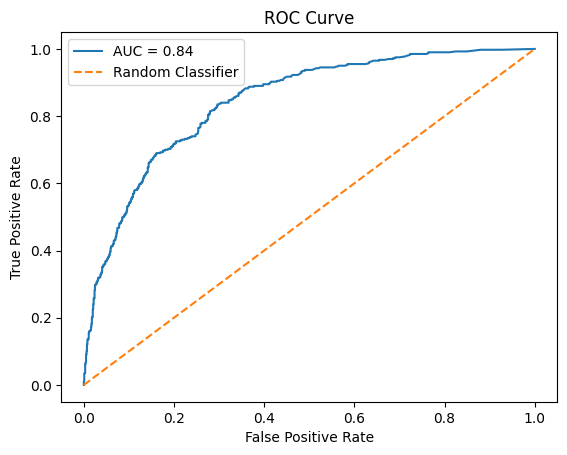

In [190]:
# Probabilities
y_prob = rf.predict_proba(X_test)
churn_prob = y_prob[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(Y_test, churn_prob)

# AUC score
auc_score = roc_auc_score(Y_test, churn_prob)
print("AUC Score:", auc_score)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Customer Segmentation using KMeans Clustering

In [191]:
churn_probability = rf.predict_proba(X)[:, 1]
segmentation_data = pd.DataFrame({
    'Tenure Months': X['Tenure Months'],
    'Monthly Charges': X['Monthly Charges'],
    'Total Charges': X['Total Charges'],
    'Churn Probability': churn_probability
})
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.783718
1,2,70.70,151.65,0.849031
2,8,99.65,820.50,0.872869
3,28,104.80,3046.05,0.698000
4,49,103.70,5036.30,0.699947
...,...,...,...,...
7038,72,21.15,1419.40,0.002000
7039,24,84.80,1990.50,0.010000
7040,72,103.20,7362.90,0.002000
7041,11,29.60,346.45,0.107582


### Implementation of KMeans

In [192]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.58547665]
 [-1.23672422  0.19736523 -0.93887444  1.78594164]
 [-0.99240204  1.1595457  -0.64378925  1.85910773]
 [-0.17799476  1.33071079  0.3380854   1.32238472]
 [ 0.67713287  1.29415125  1.2161497   1.32836115]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

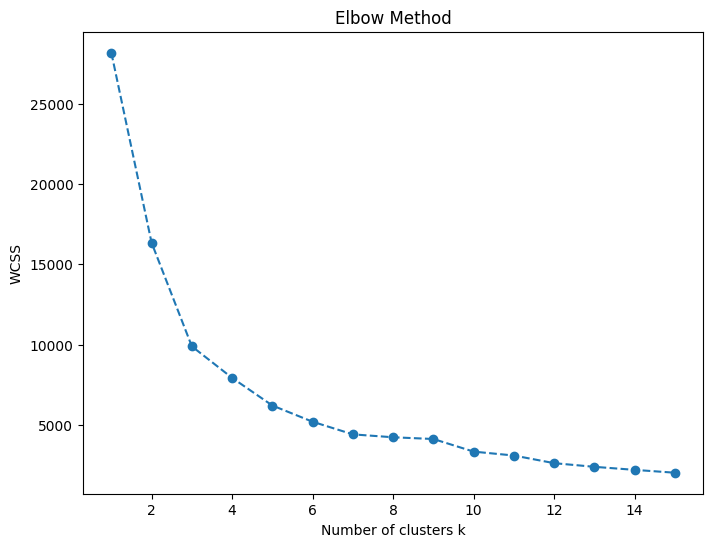

In [193]:
from sklearn.cluster import KMeans

wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o',linestyle='--')
plt.xlabel('Number of clusters k')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [194]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters =  kmeans.fit_predict(scaled_data)
segmentation_data['Cluster'] = clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.783718,2
1,2,70.70,151.65,0.849031,2
2,8,99.65,820.50,0.872869,2
3,28,104.80,3046.05,0.698000,2
4,49,103.70,5036.30,0.699947,1
...,...,...,...,...,...
7038,72,21.15,1419.40,0.002000,0
7039,24,84.80,1990.50,0.010000,0
7040,72,103.20,7362.90,0.002000,1
7041,11,29.60,346.45,0.107582,0


In [195]:
cluster_summary = segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,27.381053,38.287734,962.997137,0.069705
1,57.636364,90.146985,5185.281436,0.126171
2,11.275602,74.043173,908.712073,0.704833


In [196]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: 'High Risk New Customers',
    2: 'Loyal Premium Customers'
}
segmentation_data['Cluster Segment'] = segmentation_data['Cluster'].map(cluster_names)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.783718,2,Loyal Premium Customers
1,2,70.70,151.65,0.849031,2,Loyal Premium Customers
2,8,99.65,820.50,0.872869,2,Loyal Premium Customers
3,28,104.80,3046.05,0.698000,2,Loyal Premium Customers
4,49,103.70,5036.30,0.699947,1,High Risk New Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.002000,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.010000,0,Budget Loyal Customers
7040,72,103.20,7362.90,0.002000,1,High Risk New Customers
7041,11,29.60,346.45,0.107582,0,Budget Loyal Customers


### Cluster Visualizations

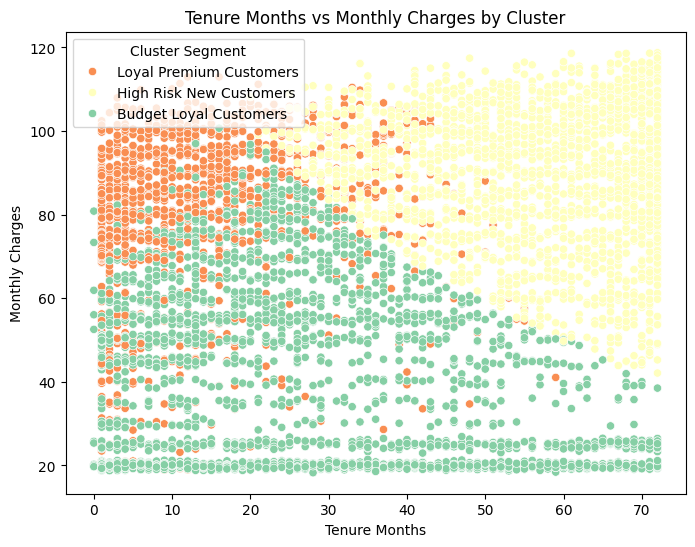

In [197]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x = 'Tenure Months', y = 'Monthly Charges', hue = 'Cluster Segment', data = segmentation_data, palette = 'Spectral')
plt.title('Tenure Months vs Monthly Charges by Cluster')
plt.show()

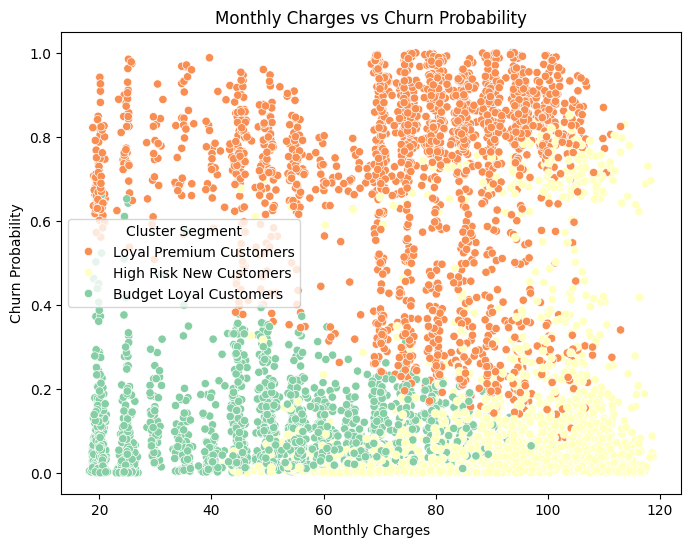

In [198]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x = 'Monthly Charges', y = 'Churn Probability', hue = 'Cluster Segment', data = segmentation_data, palette = 'Spectral')
plt.title('Monthly Charges vs Churn Probability')
plt.show()

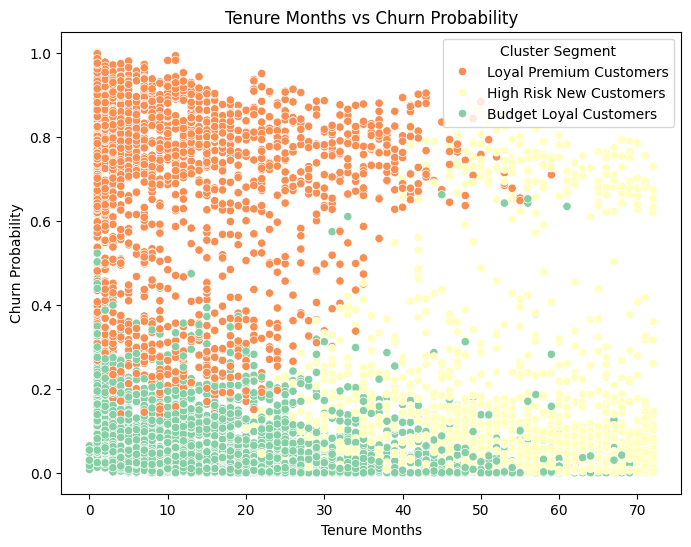

In [199]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x = 'Tenure Months', y = 'Churn Probability', hue = 'Cluster Segment', data = segmentation_data, palette = 'Spectral')
plt.title('Tenure Months vs Churn Probability')
plt.show()

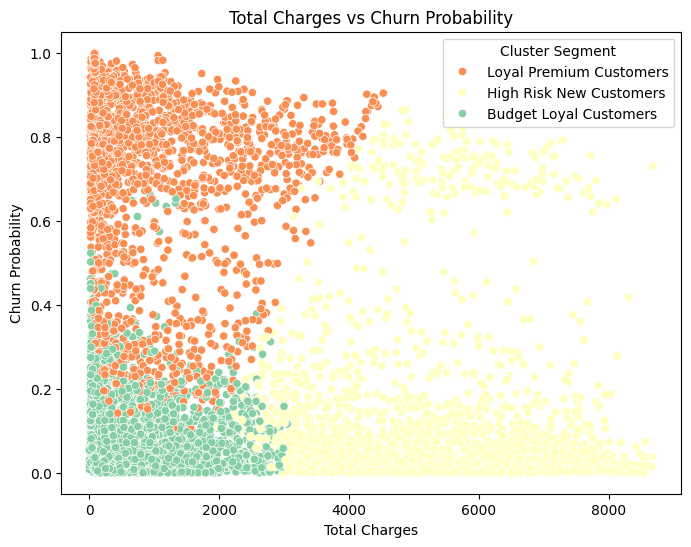

In [200]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='Churn Probability',
                hue='Cluster Segment', data=segmentation_data, palette='Spectral')
plt.title('Total Charges vs Churn Probability')
plt.show()

###Business Impact

In [201]:
total_customers = len(Y_test)

# actual churners
actual_churners = sum(Y_test)

# correctly predicted churners
correct_churn = ((y_pred_tuned == 1) & (Y_test == 1)).sum()

# missed churners
missed_churn = actual_churners - correct_churn

# revenue assumption
avg_revenue = 65

print("Total Customers:", total_customers)
print("Actual Churners:", actual_churners)
print("Correctly Predicted Churners:", correct_churn)
print("Missed Churners:", missed_churn)

print("\nEstimated Revenue Saved:", correct_churn * avg_revenue)
print("Revenue Lost:", missed_churn * avg_revenue)

Total Customers: 1409
Actual Churners: 400
Correctly Predicted Churners: 301
Missed Churners: 99

Estimated Revenue Saved: 19565
Revenue Lost: 6435
